# Programa de Capacitação de Processamento Digital de Sinais


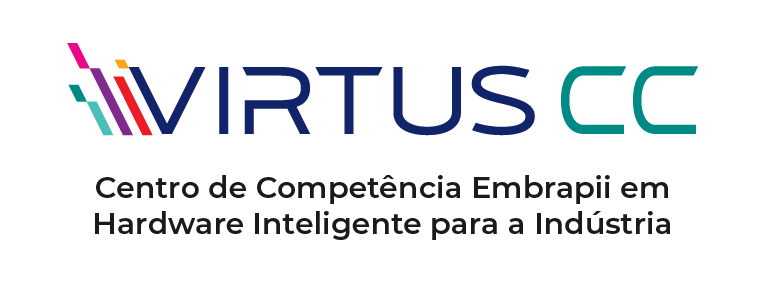


### Desenvolvido por:
-   Elmer Pimentel Farias


## Exercícios do Capítulo 3 — Processamento Digital de Sinais

Capítulo 3 do livro **Processamento Digital de Sinais** de Paulo S. R. Diniz.

## Sobre o Capítulo 3

**O Capítulo 3 apresenta os conceitos de DFT e implementações de FFT:**

- Análise de Frequência de Sinais Discretos: Por que representar sinais no domínio da frequência.

- A Transformada de Fourier Discreta (DFT): A versão computacional da análise de Fourier.

- Definição e Propriedades Principais.

A **Transformada Rápida de Fourier (FFT)** não é uma nova transformada, mas sim uma família de algoritmos extremamente eficientes para calcular a DFT.

- A ineficiência do cálculo direto da DFT: O cálculo da DFT diretamente por sua definição exige um número de operações na ordem de **$O(N^2)$**, onde $N$ é o número de amostras. Isso torna o processo inviável para sequências longas.

- O princípio da "divisão e conquista": A base dos algoritmos FFT é quebrar uma DFT de $N$ pontos em DFTs menores, de forma recursiva. Os resultados dessas DFTs menores são então combinados para produzir o resultado final.


- Algoritmos Clássicos: Os algoritmos mais comuns que implementam essa estratégia são:
    - Decimação no Tempo (DIT - *Decimation-In-Time*)
    - Decimação na Frequência (DIF - *Decimation-In-Frequency*)


- O ganho de performance: Ao utilizar a estratégia de "divisão e conquista", os algoritmos FFT reduzem drasticamente a complexidade computacional para a ordem de **$O(N \log N)$**, representando um ganho de performance massivo e tornando a análise de frequência uma ferramenta prática na computação moderna.

- Métodos Overlap-Add e Overlap-Save 

- Convolução Circular vs. Linear: Como a DFT modifica a operação de convolução e como usar isso a nosso favor.

## Objetivos Principais:
-  Implementar DFT manualmente e verificar propriedades como simetria e periodicidade.
-   Implementar o algoritmo da FFT e comparar tempo de execução e resultado com a DFT
-  Simular convolução circular via DFT e comparar com convolução linear.
- Testar ferramentas de aceleração de código, tais como Numba e CuPy.

## Vamos utilizar bibliotecas Python para representação e manipulação de sinais discretos

- NumPy : https://numpy.org/doc/stable/user/absolute_beginners.html
- Matplotlib.pyplot: https://matplotlib.org/3.5.3/api/_as_gen/matplotlib.pyplot.html

# Importando as Bibliotecas


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

Sinal x1[n] com zero padding: 50 amostras
Sinal x2[n] cortado: 100 amostras


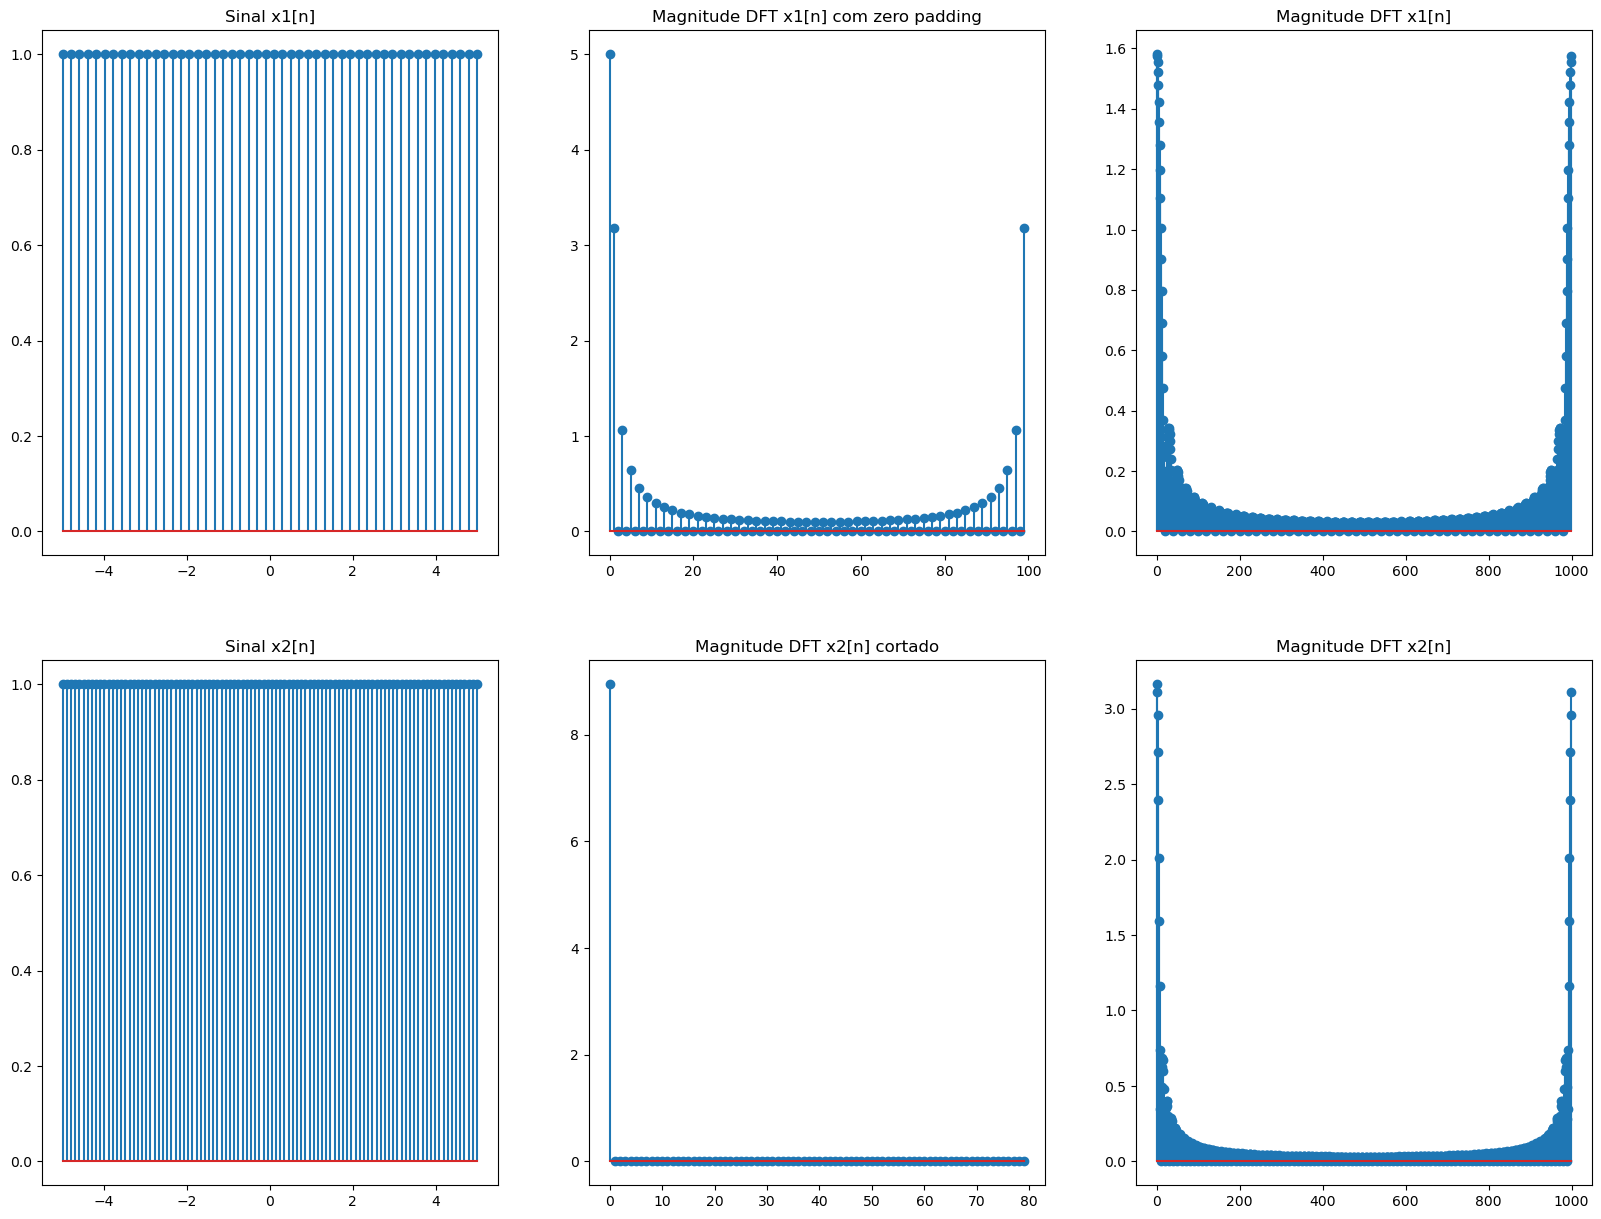

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal  

from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT

L1= 50
N1= 100

L2=100
N2=80 

n1= np.linspace(-5,5,L1)
n2= np.linspace(-5,5,L2)

x1= np.where(np.abs(n1)<10,1,0) #sinal retangular
x2= np.where(np.abs(n2)<10,1,0) #sinal retangular



X1_DFT= DFT_func(x1,N=N1) #DFT do sinal x1, L1=50 < N1=100, com zero padding

X2_DFT= DFT_func(x2,N=N2) #DFT do sinal x2, L2=100 > N2=80, truncado

X3_DFT= DFT_func(x1,N=1000) #DFT do sinal x2, L2=100 < N=1000

X4_DFT= DFT_func(x2,N=1000) #DFT do sinal x2, L2=100 > N=1000

fig , axs= plt.subplots(2,3, figsize=(20,15))

axs[0,0].stem(n1,x1)
axs[0,0].set_title('Sinal x1[n]')
axs[1,0].stem(n2,x2)
axs[1,0].set_title('Sinal x2[n]')
axs[0,1].stem(np.abs(X1_DFT))
axs[0,1].set_title('Magnitude DFT x1[n] com zero padding')
axs[1,1].stem(np.abs(X2_DFT))
axs[1,1].set_title('Magnitude DFT x2[n] cortado')
axs[0,2].stem(np.abs(X3_DFT))
axs[0,2].set_title('Magnitude DFT x1[n]')
axs[1,2].stem(np.abs(X4_DFT))
axs[1,2].set_title('Magnitude DFT x2[n]')

print('Sinal x1[n] com zero padding:', len(x1), 'amostras')
print('Sinal x2[n] cortado:', len(x2), 'amostras')

## Otimização de Código

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, jit , vectorize , prange
@njit(parallel=True)
def DFT_func_Numba(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


def DFT_func(signal, N):
    L = len(signal)  # tamanho do sinal

    sig = np.zeros(N, dtype=signal.dtype) # inicializa o vetor do sinal com zeros de tamanho N do tipo do sinal
    if L < N:
        sig[:L] = signal  # zero padding
    else:
        sig = signal[0:N]  # truncar

    X = np.zeros(N, dtype=np.complex128)  # inicializa o vetor da DFT com zeros
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))  # soma os valores da DFT

    return X / np.sqrt(N)  # normaliza a DFT


dft_tamanhos= [64,128,256,512,1024,2048]        
tempo_DFT= []
tempo_DFT_Numba= []

fs= 1000 # frequência de amostragem
f= 50 # frequência do sinal
A= 1 # amplitude do sinal
t= np.arange(-1,1,1/fs) # vetor tempo
x= A * np.sin(2 * np.pi * f * t) # sinal senoidal
x_noise= x + 0.5 * np.random.randn(len(t)) # sinal com ruído

for N in dft_tamanhos:
    print('Para N= {N}')
    start_time= time.time()
    X_DFT= DFT_func(x_noise,N)
    end_time= time.time()
    time_spent= end_time - start_time
    tempo_DFT.append(time_spent)
    print(f'Tempo DFT: {time_spent} segundos')
    

Aquecendo o compilador Numba...
Aquecimento concluído.

Testando para N = 64...
  Python Puro: 0.0119 segundos
  Numba:       0.0002 segundos
Testando para N = 128...
  Python Puro: 0.0425 segundos
  Numba:       0.0004 segundos
Testando para N = 256...
  Python Puro: 0.1511 segundos
  Numba:       0.0015 segundos
Testando para N = 512...
  Python Puro: 0.6665 segundos
  Numba:       0.0053 segundos
Testando para N = 1024...
  Python Puro: 2.5028 segundos
  Numba:       0.0100 segundos
Testando para N = 2048...
  Python Puro: 9.8681 segundos
  Numba:       0.0382 segundos


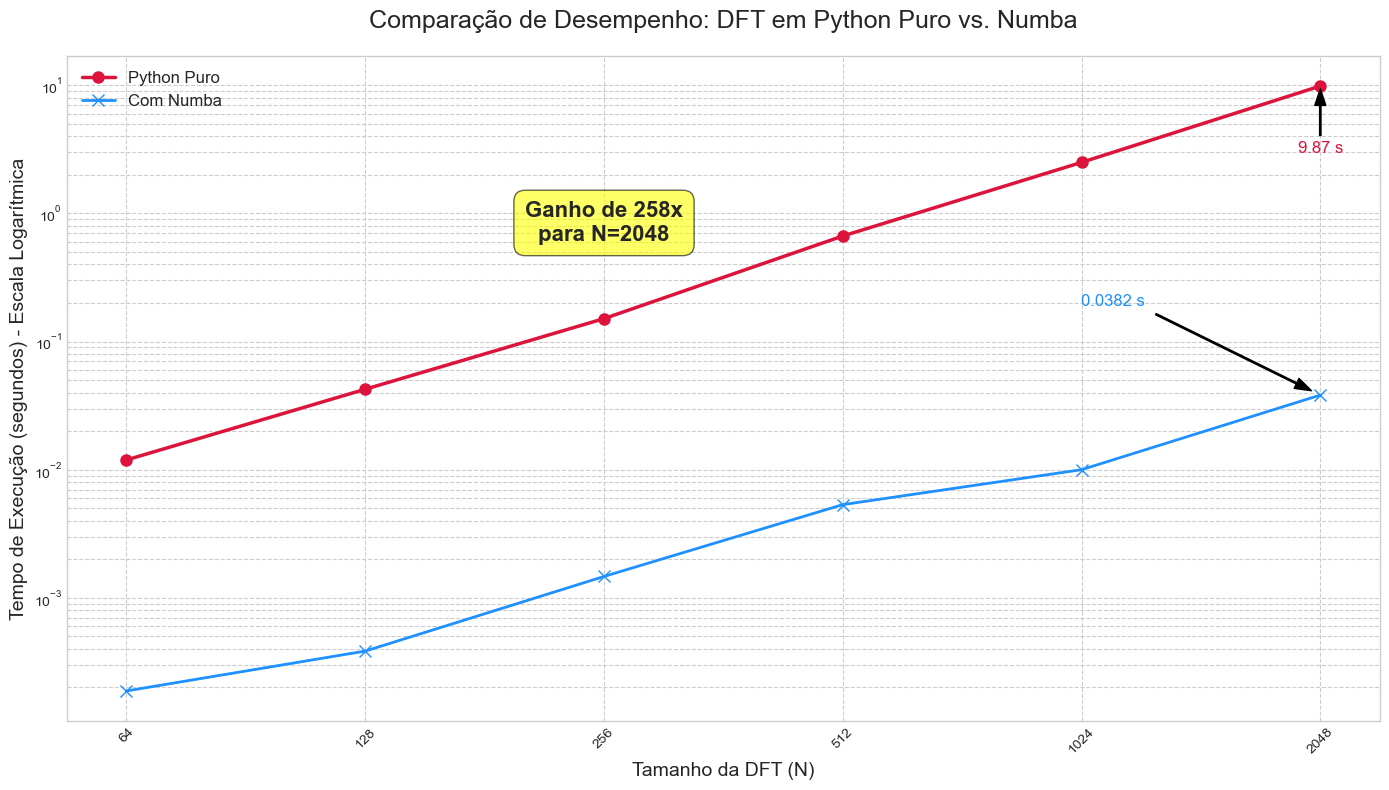

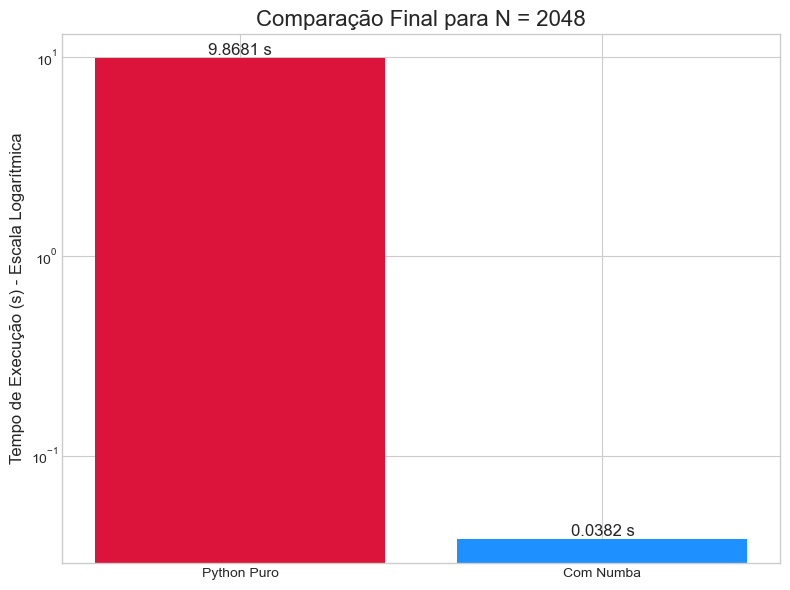


Para N = 2048, a versão com Numba foi 258.09 vezes mais rápida!


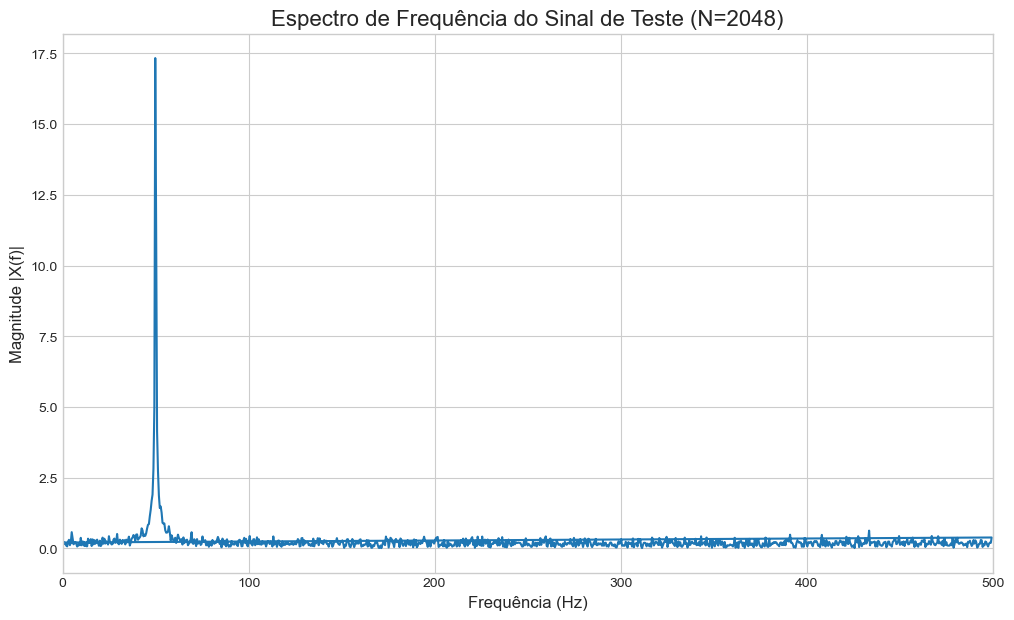

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import njit, prange

# --- As duas funções DFT (DFT_pure_python e DFT_numba) permanecem exatamente as mesmas ---

def DFT_pure_python(signal, N):
    L = len(signal)
    sig = np.zeros(N, dtype=signal.dtype)
    if L < N:
        sig[:L] = signal
    else:
        sig = signal[:N]
    X = np.zeros(N, dtype=np.complex128)
    for k in range(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))
    return X / np.sqrt(N)

@njit(parallel=True)
def DFT_numba(signal, N):
    L = len(signal)
    sig = np.zeros(N, dtype=signal.dtype)
    if L < N:
        sig[:L] = signal
    else:
        sig = signal[:N]
    X = np.zeros(N, dtype=np.complex128)
    for k in prange(N):
        for n in range(N):
            X[k] += sig[n] * (np.exp((-2j * np.pi * k * n) / N))
    return X / np.sqrt(N)

# --- O EXPERIMENTO (COM SINAL DE COSSENO + RUÍDO) ---

# 1. Definir os tamanhos de N que vamos testar
tamanhos_dft = [64, 128, 256, 512, 1024, 2048]
tempos_python = []
tempos_numba = []

# --- PARÂMETROS DO SINAL DE TESTE (NOVA SEÇÃO) ---
fs = 1000.0                # Taxa de amostragem: 1000 Hz
frequencia_sinal = 50.0    # Frequência do cosseno: 50 Hz
amplitude_sinal = 1.0      # Amplitude do cosseno
amplitude_ruido = 0.2      # Amplitude do ruído (20% da amplitude do sinal)

# Aquecer o Numba (sem alterações aqui)
print("Aquecendo o compilador Numba...")
sinal_aquecimento = np.random.randn(10)
DFT_numba(sinal_aquecimento, 10)
print("Aquecimento concluído.\n")

# 2. Loop para testar cada tamanho de N
for N in tamanhos_dft:
    print(f"Testando para N = {N}...")
    
    # --- GERAÇÃO DO SINAL DE TESTE (PARTE MODIFICADA) ---
    # Em vez de np.random.randn(N), agora criamos um sinal mais complexo.
    
    # 1. Criar um eixo de tempo discreto
    t = np.arange(N) / fs
    
    # 2. Criar o sinal de cosseno puro
    sinal_puro = amplitude_sinal * np.cos(2 * np.pi * frequencia_sinal * t)
    
    # 3. Criar o ruído
    ruido = amplitude_ruido * np.random.randn(N)
    
    # 4. Somar o sinal puro com o ruído
    sinal_teste = sinal_puro + ruido
    # --- FIM DA MODIFICAÇÃO ---

    # Medir tempo da função em Python Puro (sem alterações aqui)
    start_time = time.perf_counter()
    DFT_pure_python(sinal_teste, N)
    end_time = time.perf_counter()
    tempo_gasto_python = end_time - start_time
    tempos_python.append(tempo_gasto_python)
    print(f"  Python Puro: {tempo_gasto_python:.4f} segundos")

    # Medir tempo da função com Numba (sem alterações aqui)
    start_time = time.perf_counter()
    # Guardar o resultado da última execução para o gráfico bônus
    if N == tamanhos_dft[-1]:
        X_final_numba = DFT_numba(sinal_teste, N)
    else:
        DFT_numba(sinal_teste, N)
    end_time = time.perf_counter()
    tempo_gasto_numba = end_time - start_time
    tempos_numba.append(tempo_gasto_numba)
    print(f"  Numba:       {tempo_gasto_numba:.4f} segundos")

# --- PLOTANDO OS RESULTADOS DE TEMPO (sem alterações aqui) ---
# --- PLOTANDO OS RESULTADOS (VERSÃO MELHORADA PARA MAIOR CLAREZA) ---

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 8))

# 1. Plotar as linhas com cores e marcadores mais destacados
ax.plot(tamanhos_dft, tempos_python, 'o-', label='Python Puro', linewidth=2.5, markersize=8, color='crimson')
ax.plot(tamanhos_dft, tempos_numba, 'x-', label='Com Numba', linewidth=2, markersize=8, color='dodgerblue')

# 2. Configurar as escalas logarítmicas (essencial)
ax.set_yscale('log')
ax.set_xscale('log', base=2)

# 3. Adicionar títulos e legendas
ax.set_title('Comparação de Desempenho: DFT em Python Puro vs. Numba', fontsize=18, pad=20)
ax.set_xlabel('Tamanho da DFT (N)', fontsize=14)
ax.set_ylabel('Tempo de Execução (segundos) - Escala Logarítmica', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', linestyle='--')

# 4. Configurar os ticks do eixo X para mostrar todos os tamanhos testados
ax.set_xticks(tamanhos_dft)
ax.set_xticklabels(tamanhos_dft, rotation=45) # Rotacionar para não sobrepor

# 5. --- A MÁGICA: ANOTAÇÕES NO GRÁFICO ---
# Anotar o último ponto da linha do Python
ultimo_tempo_py = tempos_python[-1]
ultimo_N = tamanhos_dft[-1]
ax.annotate(f'{ultimo_tempo_py:.2f} s', 
            xy=(ultimo_N, ultimo_tempo_py),
            xytext=(ultimo_N, ultimo_tempo_py * 0.3), # Posição do texto
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
            fontsize=12, color='crimson', horizontalalignment='center')

# Anotar o último ponto da linha do Numba
ultimo_tempo_nb = tempos_numba[-1]
ax.annotate(f'{ultimo_tempo_nb:.4f} s',
            xy=(ultimo_N, ultimo_tempo_nb),
            xytext=(ultimo_N * 0.6, ultimo_tempo_nb * 5), # Posição do texto
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
            fontsize=12, color='dodgerblue', horizontalalignment='right')

# Adicionar o texto principal de speedup
speedup = ultimo_tempo_py / ultimo_tempo_nb
ax.text(tamanhos_dft[2], (ultimo_tempo_py * ultimo_tempo_nb)**0.5, # Posição central
        f'Ganho de {speedup:.0f}x\npara N={ultimo_N}',
        fontsize=16,
        fontweight='bold',
        ha='center',
        bbox=dict(boxstyle="round,pad=0.5", fc='yellow', alpha=0.6))

plt.tight_layout()
plt.show()


# --- BÔNUS: GRÁFICO DE BARRAS PARA COMPARAÇÃO FINAL ---
fig_bar, ax_bar = plt.subplots(figsize=(8, 6))

labels = ['Python Puro', 'Com Numba']
tempos_finais = [ultimo_tempo_py, ultimo_tempo_nb]
cores = ['crimson', 'dodgerblue']

bars = ax_bar.bar(labels, tempos_finais, color=cores)

ax_bar.set_yscale('log') # Escala logarítmica também é útil aqui
ax_bar.set_ylabel('Tempo de Execução (s) - Escala Logarítmica', fontsize=12)
ax_bar.set_title(f'Comparação Final para N = {ultimo_N}', fontsize=16)

# Adicionar os valores exatos no topo de cada barra
ax_bar.bar_label(bars, fmt='%.4f s', fontsize=12)

plt.tight_layout()
plt.show()

# --- ANÁLISE FINAL (sem alterações aqui) ---
print(f"\nPara N = {tamanhos_dft[-1]}, a versão com Numba foi {speedup:.2f} vezes mais rápida!")

# --- O GRÁFICO DO ESPECTRO PERMANECE O MESMO ---
# (Se quiser rodar o resto do código para ver o espectro, não precisa mudar nada)
N_final = tamanhos_dft[-1]
freqs = np.fft.fftfreq(N_final, d=1/fs)
plt.figure(figsize=(12, 7))
plt.plot(freqs, np.abs(X_final_numba))
plt.title(f'Espectro de Frequência do Sinal de Teste (N={N_final})', fontsize=16)
plt.xlabel('Frequência (Hz)', fontsize=12)
plt.ylabel('Magnitude |X(f)|', fontsize=12)
plt.xlim(0, fs / 2)
plt.grid(True)
plt.show()